In [ ]:
from datasets import load_dataset

# Load the dataset
dataset = load_dataset("taresh18/AnimeVox")

# Access the training split
train_data = dataset["train"]

# Print dataset information
print(f"Dataset contains {len(train_data)} samples")

# Access a specific sample
sample = train_data[0]
print(f"Character: {sample['character_name']}")
print(f"From anime: {sample['anime']}")
print(f"Transcription: {sample['transcription']}")

107428


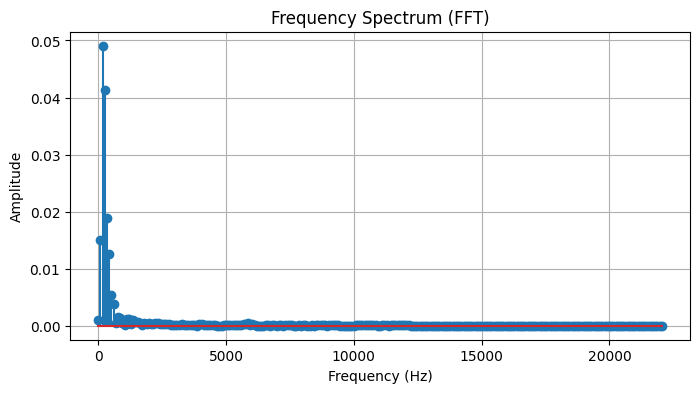

[-1.00615587e+02  1.53000946e+01  6.13508412e+00  4.05199184e+00
  2.85986299e+00  2.88236094e+00  1.83821358e+00  5.94991006e-01
  5.43504791e-02  1.42564082e-01 -6.99682254e-01 -7.22478377e-01
  8.74169685e-02]


In [ ]:
import matplotlib.pyplot as plt
import librosa
import numpy as np
sample = train_data[500]
audio_data1 = sample['audio']['array']
sampling_rate1 = sample['audio']['sampling_rate']

print(audio_data1.size)
f=0
framelength=512
hooplegth=160
anew=audio_data1[f:f+framelength]
window = np.hanning(framelength)
windowframe = anew * window
fft = np.fft.rfft(windowframe) #even 512 error of 1 n/2+1 we take negitive last and remove it so rrft better

frequencies = np.fft.rfftfreq(framelength, d=1/sampling_rate1)

magnitude = np.abs(fft) * 2 / framelength
magnitude[0] /= 2
magnitude[-1] /= 2   # Nyquist bin should also not be doubled

    # steven buston video

  # into 2 becaue of negitive values

plt.figure(figsize=(8, 4))
plt.stem(frequencies[frequencies>=0], magnitude)

  # do we take power do we divide by n do we take log after that i don't know

plt.title("Frequency Spectrum (FFT)")
plt.xlabel("Frequency (Hz)")
plt.ylabel("Amplitude")

plt.grid(True)
plt.show()
power = magnitude ** 2
fban= librosa.filters.mel(sr=sampling_rate1, n_fft=framelength, n_mels=26)
mel_values = np.dot(fban, power)
log_mel = np.log(mel_values + 1e-10)  # small epsilon to avoid log(0)
from scipy.fft import dct
mfcc_coeffs = dct(log_mel, type=2, norm='ortho')[:13]
print(mfcc_coeffs)








In [ ]:
#gmm-uba
# ============================================================
# STEP 0: Imports
# ============================================================
import numpy as np
import librosa
from tqdm import tqdm
from collections import defaultdict
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.mixture import GaussianMixture

# ============================================================
# STEP 1: Check character counts, filter out characters with too few samples
# ============================================================
from collections import Counter

label_counts = Counter(train_data['character_name'])
valid_chars = {c for c, n in label_counts.items() if n >= 5}  # need >=5 for stratified split

keep_idx = [i for i, c in enumerate(train_data['character_name']) if c in valid_chars]
filtered_data = train_data.select(keep_idx)

print(f"Kept {len(valid_chars)} characters, {len(filtered_data)} samples "
      f"(dropped {len(train_data) - len(filtered_data)} samples from rare characters)")

# ============================================================
# STEP 2: Stratified train/test split (by character proportion)
# ============================================================
indices = list(range(len(filtered_data)))
labels = filtered_data['character_name']

train_idx, test_idx = train_test_split(
    indices,
    test_size=0.2,
    stratify=labels,
    random_state=42
)

train_split = filtered_data.select(train_idx)
test_split = filtered_data.select(test_idx)

print(f"Train: {len(train_split)} samples | Test: {len(test_split)} samples")

# ============================================================
# STEP 3: Feature extraction function (MFCC + delta + delta-delta)
# ============================================================
def extract_features(audio_array, sr, n_mfcc=13, n_fft=512, hop_length=160):
    mfcc = librosa.feature.mfcc(y=audio_array, sr=sr, n_mfcc=n_mfcc, n_fft=n_fft, hop_length=hop_length)
    delta = librosa.feature.delta(mfcc, order=1)
    delta2 = librosa.feature.delta(mfcc, order=2)
    features = np.vstack([mfcc, delta, delta2])   # shape (39, n_frames)
    return features.T                              # shape (n_frames, 39)

def extract_split(split):
    feats_list = []
    labels_list = []
    for i in tqdm(range(len(split)), desc="Extracting features"):
        sample = split[i]
        audio = sample['audio']['array']
        sr = sample['audio']['sampling_rate']
        feats = extract_features(audio, sr)
        feats_list.append(feats)
        labels_list.append(sample['character_name'])
    return feats_list, labels_list

# ============================================================
# STEP 4: Extract features for train and test
# ============================================================
train_features, train_labels = extract_split(train_split)
test_features, test_labels = extract_split(test_split)

# ============================================================
# STEP 5: Fit scaler on TRAIN only, apply to both train and test
# ============================================================
stacked_train = np.vstack(train_features)   # all frames from all train clips
scaler = StandardScaler()
scaler.fit(stacked_train)

train_features_scaled = [scaler.transform(f) for f in train_features]
test_features_scaled = [scaler.transform(f) for f in test_features]

# ============================================================
# STEP 6: Group train frames by character
# ============================================================
char_frames = defaultdict(list)
for feats, label in zip(train_features_scaled, train_labels):
    char_frames[label].append(feats)

# ============================================================
# STEP 7: Train one GMM per character (adaptive n_components)
# ============================================================
gmms = {}

for char, frame_list in tqdm(char_frames.items(), desc="Training GMMs"):
    pooled = np.vstack(frame_list)   # (total_frames_for_char, 39)
    n_frames = pooled.shape[0]

    # scale components with available data; never below 2, capped at 16
    n_components = min(16, max(2, n_frames // 200))

    gmm = GaussianMixture(
        n_components=n_components,
        covariance_type='diag',
        max_iter=200,
        random_state=42
    )
    gmm.fit(pooled)
    gmms[char] = gmm

print(f"Trained {len(gmms)} GMMs")

# ============================================================
# STEP 8: Predict function
# ============================================================
def predict_character(feats_scaled, gmms):
    scores = {char: gmm.score(feats_scaled) for char, gmm in gmms.items()}
    best_char = max(scores, key=scores.get)
    return best_char, scores

# ============================================================
# STEP 9: Evaluate on test set
# ============================================================
correct = 0
total = 0
confusions = []   # store (true, predicted) for wrong predictions

for feats, true_label in tqdm(zip(test_features_scaled, test_labels), total=len(test_labels), desc="Evaluating"):
    pred_label, _ = predict_character(feats, gmms)
    if pred_label == true_label:
        correct += 1
    else:
        confusions.append((true_label, pred_label))
    total += 1

accuracy = correct / total
print(f"\nAccuracy: {accuracy:.2%} ({correct}/{total})")

# ============================================================
# STEP 10 (optional): Peek at most common confusions
# ============================================================
if confusions:
    confusion_counts = Counter(confusions)
    print("\nTop confused pairs (true -> predicted):")
    for (true_c, pred_c), n in confusion_counts.most_common(10):
        print(f"  {true_c} -> {pred_c}: {n} times")

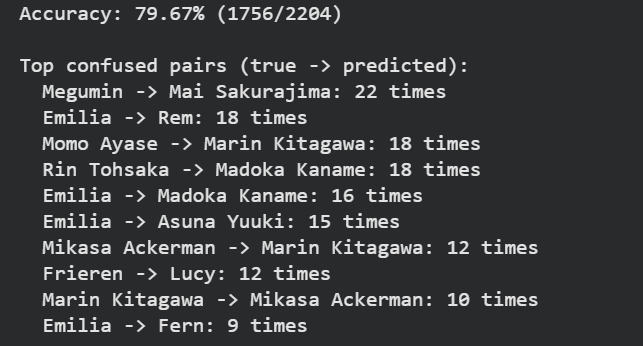